In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\projects\data\general\Export.xlsx - Sheet1.csv',sep=',')
unit.info()

<class 'pandas.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  1078 non-null   str  
 1   Message  1078 non-null   str  
 2   Status   1078 non-null   str  
dtypes: str(3)
memory usage: 25.4 KB


[0, 0, 1, 0, 0, 0, 0, 0, 1, 48, 32, 32, 27, 29, 33, 34, 29, 46, 0, 39, 0, 12, 16, 20, 14, 19, 7, 14, 10, 11, 15, 11, 0, 0, 5, 2, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 6, 7, 0, 0, 0, 3, 3, 1, 0, 1, 2, 1, 1, 0, 3, 1, 0, 0, 0, 0, 0, 5, 25, 15, 0, 31, 0, 18, 10, 8, 14, 14, 12, 1, 0, 0, 12, 0, 0, 0, 0, 32, 13, 22, 9, 11, 2, 23, 12, 16, 11, 9, 13, 19, 15, 12, 9, 7, 6, 0, 0, 0, 0, 0, 0, 0, 114, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 24, 0, 0, 4, 23, 5, 17, 13, 15, 17, 17, 16, 19, 65, 43, 43, 47, 15, 49, 42, 58, 56, 53, 30, 52, 55, 48, 92, 73, 65, 99, 60, 79, 82, 98, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 79, 73, 12, 18, 20, 60, 82, 79, 78, 67, 70, 81, 65, 75, 70, 79, 38, 50, 22, 61, 58, 46, 36, 63, 50, 44, 0, 25, 44, 0, 49, 0, 56, 0, 53, 22, 19, 9, 11, 10, 11, 11, 0, 11, 11, 7, 11, 15, 9, 14, 12, 21, 8, 10, 0, 30, 8, 0, 0, 0, 0, 0, 116, 0, 0, 5, 29, 15, 17, 15, 14, 10, 13, 8, 10, 15, 11, 22, 15, 9, 0, 12, 9, 12, 29, 0, 52, 0, 28, 0, 34, 0, 26, 0, 41, 19, 47, 54, 60, 54, 62, 0, 0, 0, 9, 0

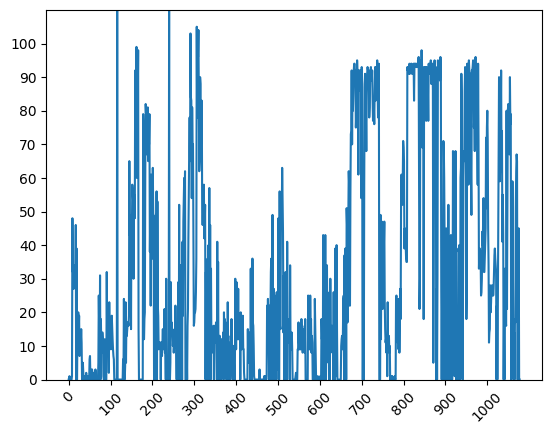

In [33]:
aux=[]
aux_kmh=[]
x_axis=[]
unit_speed=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][56:58],16))
        #aux_kmh.append((int(unit.iloc[i,2][68:76],16))*0.036)
        cont=cont+1     

unit_speed['Speed Km-h']=aux
#unit_speed['Speed m-s']=aux_kmh

for i in range(0,cont):
    x_axis.append(i)

print(aux,cont)

plt.xticks(range(0,1100,100),rotation=45)
plt.yticks(range(0,110,10))
plt.ylim(0,110)
plt.plot(x_axis,aux)

In [35]:
#Dates with values higher than 100Km/h.
for i in range (0,unit.shape[0]):
    aux=(int(unit.iloc[i,2][56:58],16))
    if aux>=100:
        print(unit.iloc[i,0],' -> ',aux)

2026-03-21 16:16:27.673  ->  114
2026-03-23 17:39:07.155  ->  116
2026-03-23 20:55:30.582  ->  103
2026-03-23 21:07:35.437  ->  105
2026-03-23 21:08:11.599  ->  104
2026-03-23 21:08:41.150  ->  104


In [36]:
vf=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\projects\data\general\vf.csv',sep=',')
vf.info()

<class 'pandas.DataFrame'>
RangeIndex: 670 entries, 0 to 669
Columns: 128 entries, Message to Unnamed: 127
dtypes: float64(6), str(122)
memory usage: 670.1 KB


In [37]:
vf['Message'].value_counts()

Message
{"notificationType":"TripInfo"              340
{"notificationType":"CameraRunningInfo"     136
{"notificationType":"AutoSnapshot"           92
{"notificationType":"DataUsage"              36
{"notificationType":"IgnitionStatus"         33
{"notificationType":"CameraEvent"            26
{"notificationType":"MaintenanceWarning"      5
{"notificationType":"PowerEvent"              2
Name: count, dtype: int64

In [38]:
vf_camera_events=vf[vf['Message'].str.contains('CameraEvent')]
vf_camera_events['Unnamed: 4'].value_counts()

Unnamed: 4
event:"HARD_BRAKE"                      9
event:"USING_PHONE"                     4
event:"HEADWAY_MONITORING_EMERGENCY"    4
event:"YAWN"                            3
event:"HARSH_TURN"                      1
event:"POTENTIAL_INCIDENT_LOW"          1
event:"HARSH_BRAKE"                     1
event:"MANUAL"                          1
event:"HARD_ACCEL"                      1
event:"NO_SEATBELT"                     1
Name: count, dtype: int64

In [39]:
vf_camera_events['Unnamed: 5'].value_counts()

Unnamed: 5
eventCategory:"HARD_BRAKE"            10
eventCategory:"DMS"                    8
eventCategory:"HEADWAY_MONITORING"     4
eventCategory:"SHARP_TURN"             1
eventCategory:"POTENTIAL_INCIDENT"     1
eventCategory:"MANUAL"                 1
eventCategory:"HARD_ACCEL"             1
Name: count, dtype: int64